![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

## Revisión incial y limpieza

### Columnas y cantidad de registros. Tipos de datos.

In [4]:
df_model = dataTraining.copy()

In [5]:
df_model.shape

(79800, 21)

In [6]:
df_model.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'popularity'],
      dtype='object')

In [7]:
df_model.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


### Revisión de nulos
No se encuentran registros con valores nulos.

In [8]:
df_model.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


### Eliminar columnas irrelevantes
Las columnas "Unnamed: 0" y "track_id" no aportan información para la predicción.

In [9]:
df_model = df_model.drop(columns=["Unnamed: 0", "track_id"])

In [10]:
df_model.head()

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


### Eliminar registros duplicados

In [11]:
df_model.duplicated().sum()

np.int64(303)

In [12]:
df_model[df_model.duplicated(keep=False)].sort_values(by="track_name")

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
75807,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"12 Variations in C Major on ""Ah, vous dirai-je...",41893,False,0.212,0.2210,0,-20.543,1,0.0454,0.9800,0.960000,0.1490,0.425,148.759,5,classical,6
19176,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"12 Variations in C Major on ""Ah, vous dirai-je...",41893,False,0.212,0.2210,0,-20.543,1,0.0454,0.9800,0.960000,0.1490,0.425,148.759,5,classical,6
58645,Wolfgang Amadeus Mozart;Danielle Laval,Mozart: A Night of Classics,"12 Variations on an Allegretto in B Flat, K.50...",45532,False,0.637,0.0220,3,-26.353,1,0.0525,0.9950,0.909000,0.1260,0.193,89.780,4,classical,24
49913,Wolfgang Amadeus Mozart;Danielle Laval,Mozart: A Night of Classics,"12 Variations on an Allegretto in B Flat, K.50...",45532,False,0.637,0.0220,3,-26.353,1,0.0525,0.9950,0.909000,0.1260,0.193,89.780,4,classical,24
67445,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"12 Variations on an Allegretto in B Flat, K.50...",65536,False,0.601,0.0588,10,-27.720,0,0.0747,0.9950,0.916000,0.0899,0.354,125.689,4,classical,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47964,Nikolai Erdenko,Шедевры цыганской музыки. Серебряная скрипка р...,Я помню вальса звук прелестный,125826,False,0.350,0.1600,7,-14.295,0,0.0401,0.9090,0.804000,0.1020,0.212,95.345,3,romance,0
60733,SUPER BEAVER,突破口 / 自慢になりたい,突破口,255080,False,0.472,0.9940,8,-1.786,1,0.1140,0.0259,0.000000,0.0535,0.262,103.512,4,anime,54
21474,SUPER BEAVER,突破口 / 自慢になりたい,突破口,255080,False,0.472,0.9940,8,-1.786,1,0.1140,0.0259,0.000000,0.0535,0.262,103.512,4,anime,54
48679,TACOYAKI RAINBOW,絶唱!なにわで生まれた少女たち (Special Edition),絶唱!なにわで生まれた少女たち,274413,False,0.610,0.9530,10,-1.076,1,0.1020,0.1360,0.000218,0.3710,0.398,150.016,4,j-idol,18


In [13]:
df_model = df_model.drop_duplicates()

### Validación de la variable objetivo
Búsqueda de valores que no tengan sentido,ej: valores negativos

In [14]:
df_model["popularity"].describe()

,popularity
count,79497.000000
mean,33.358403
std,22.303882
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


## Análisis Exploratorio

### Análisis de la variable objetivo
*   Distribución de popularity
*   Estadísticas descriptivas


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

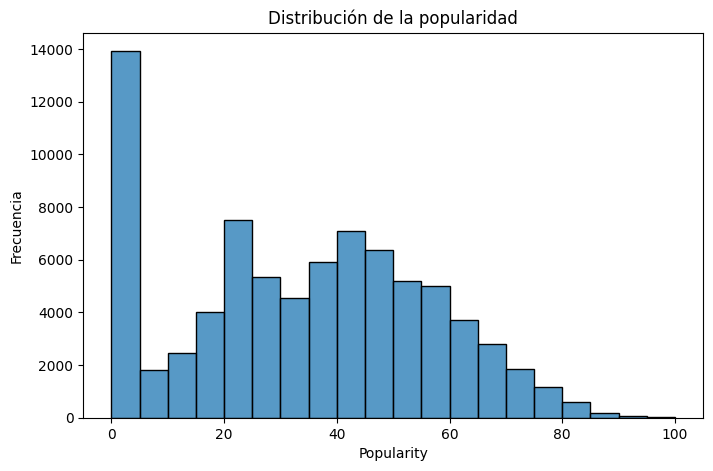

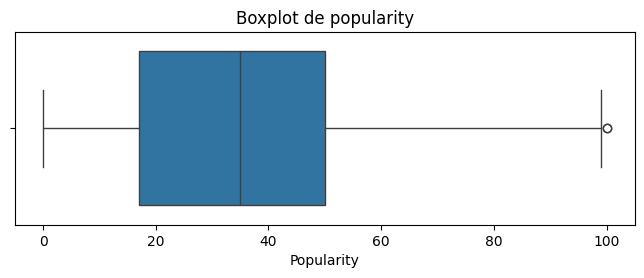

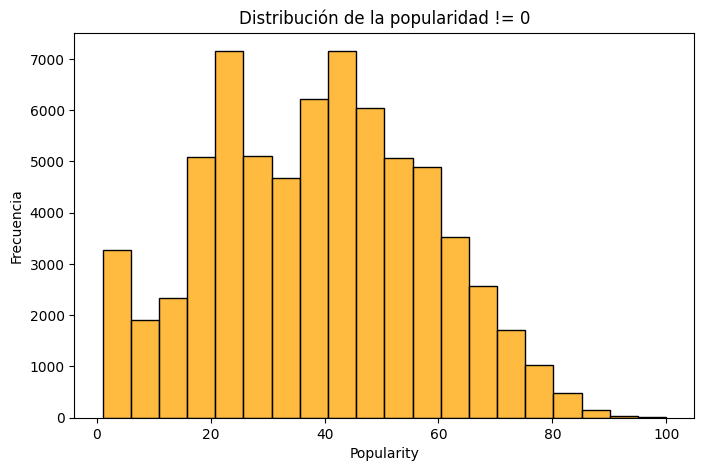

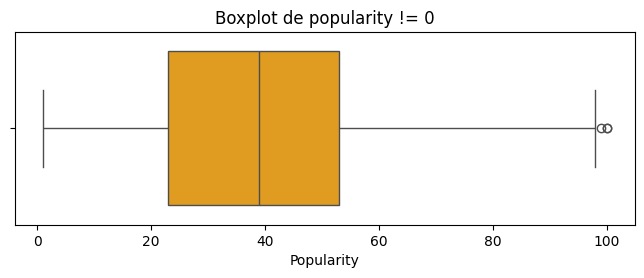


Cantidad de canciones con popularity = 0:
11066

Cantidad de canciones con popularity >= 90:
78


In [16]:
# Histograma
plt.figure(figsize=(8,5))
sns.histplot(df_model["popularity"], bins=20)
plt.title("Distribución de la popularidad")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8,2.5))
sns.boxplot(x=df_model["popularity"])
plt.title("Boxplot de popularity")
plt.xlabel("Popularity")
plt.show()

# Histograma 2
plt.figure(figsize=(8,5))
sns.histplot(df_model["popularity"][df_model["popularity"] != 0], bins=20, color="orange")
plt.title("Distribución de la popularidad != 0")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8,2.5))
sns.boxplot(x=df_model["popularity"][df_model["popularity"] != 0], color="orange")
plt.title("Boxplot de popularity != 0")
plt.xlabel("Popularity")
plt.show()

# Conteo de valores extremos
print("\nCantidad de canciones con popularity = 0:")
print((df_model["popularity"] == 0).sum())

print("\nCantidad de canciones con popularity >= 90:")
print((df_model["popularity"] >= 90).sum())

La variable popularity presenta una distribución particular caracterizada por una alta concentración de canciones con valores cercanos a cero, junto con un comportamiento más continuo en el resto de los datos. Esto sugiere la existencia de dos dinámicas dentro del dataset: un grupo amplio de canciones con baja o nula exposición, y otro grupo con distintos niveles de popularidad. Esta estructura no corresponde a una distribución completamente uniforme ni típicamente sesgada, sino a una combinación de ambos comportamientos.

Al analizar únicamente las canciones con popularidad mayor a cero, la distribución se vuelve más regular, mostrando una mayor concentración en niveles bajos y medios, y una disminución progresiva hacia valores altos. Esto indica que, incluso entre canciones con cierta visibilidad, alcanzar altos niveles de popularidad es menos frecuente. En conjunto, estos hallazgos sugieren que la variable objetivo tiene una complejidad inherente que puede influir en el desempeño del modelo, especialmente en la predicción de valores extremos.

### Análisis univariado de variables numéricas
*  Distribución de cada variable
*  Identificación de outliers
*  Rangos y escalas
*  Detección de variables con baja variabilidad

In [20]:
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [col for col in num_cols if col != "popularity"]
num_cols

['duration_ms',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

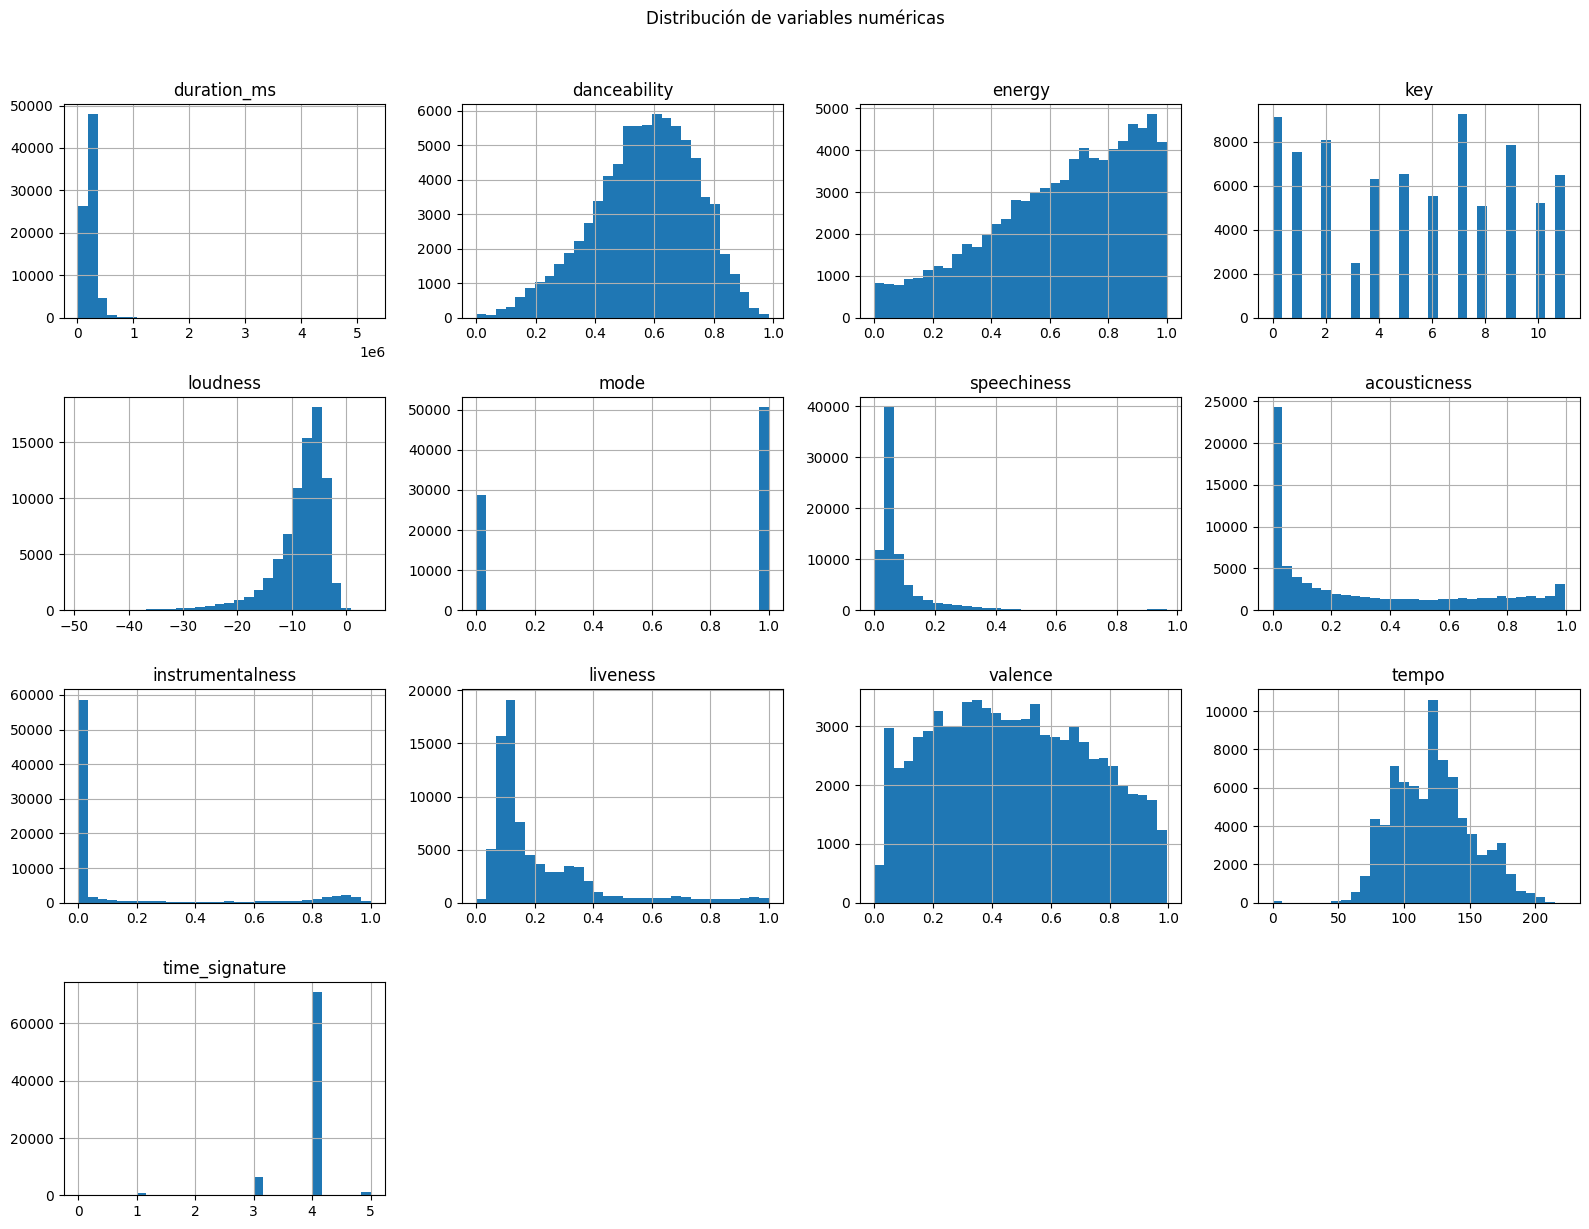

In [22]:
# Histogramas
n_cols = 4
n_rows = int(len(num_cols) / n_cols) + 1

df_model[num_cols].hist(bins=30, figsize=(16, 3*n_rows), layout=(n_rows, n_cols))

plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

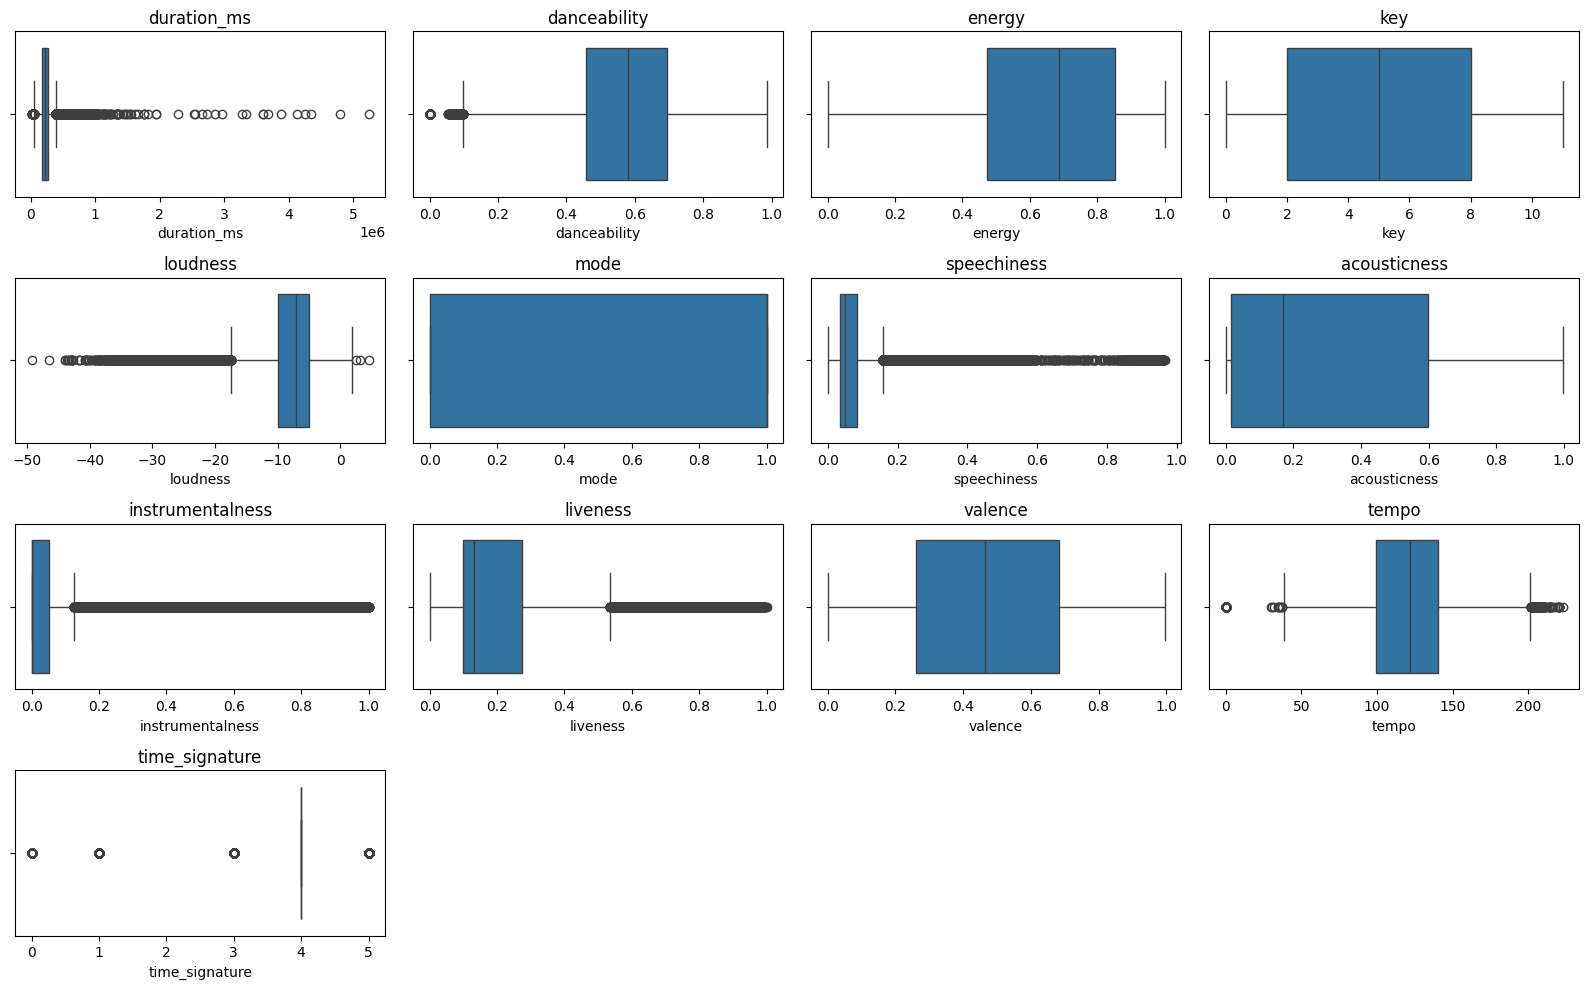

In [23]:
# Boxplots

plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df_model[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [27]:
desc = df_model[num_cols].describe().T
desc["range"] = desc["max"] - desc["min"]
desc["IQR"] = desc["75%"] - desc["25%"]

desc.round(2)

,count,mean,std,min,25%,50%,75%,max,range,IQR
duration_ms,79497.0,227960.76,103862.90,13386.00,174545.00,212903.00,261543.00,5237295.00,5223909.00,86998.00
danceability,79497.0,0.57,0.17,0.00,0.46,0.58,0.70,0.98,0.98,0.24
energy,79497.0,0.64,0.25,0.00,0.47,0.69,0.85,1.00,1.00,0.38
key,79497.0,5.31,3.56,0.00,2.00,5.00,8.00,11.00,11.00,6.00
loudness,79497.0,-8.25,5.02,-49.31,-9.99,-7.01,-5.00,4.53,53.84,5.00
mode,79497.0,0.64,0.48,0.00,0.00,1.00,1.00,1.00,1.00,1.00
speechiness,79497.0,0.08,0.11,0.00,0.04,0.05,0.08,0.96,0.96,0.05
acousticness,79497.0,0.31,0.33,0.00,0.02,0.17,0.60,1.00,1.00,0.58
instrumentalness,79497.0,0.16,0.31,0.00,0.00,0.00,0.05,1.00,1.00,0.05
liveness,79497.0,0.21,0.19,0.00,0.10,0.13,0.27,1.00,1.00,0.18


1.
2. Análisis univariado de variables numéricas
Distribución de cada variable
Identificación de outliers
Rangos y escalas
Detección de variables con baja variabilidad
3. Análisis univariado de variables categóricas
Frecuencia de categorías (track_genre, mode, key, time_signature, explicit)
Identificación de categorías dominantes
Cardinalidad de variables
4. Análisis bivariado (variables vs target)
Relación entre variables numéricas y popularity
Comparación de popularity por categorías
Detección de patrones y tendencias
5. Análisis de correlación
Matriz de correlación entre variables numéricas
Identificación de variables altamente correlacionadas
Evaluación de multicolinealidad
6. Análisis por género musical
Popularidad promedio por track_genre
Distribución de canciones por género
Variabilidad del score dentro de cada género
7. Análisis de variables clave (insights específicos)
Impacto de energy, danceability, valence
Relación de tempo y loudness con popularidad
Evaluación de variables acústicas vs popularidad
8. Análisis de relaciones entre variables (multivariado ligero)
Interacción entre variables relevantes
Patrones combinados (ej: energy + danceability)
Detección de clusters visuales
9. Detección de outliers relevantes
Outliers en variables clave
Outliers en popularity
Evaluación de impacto en el modelo
10. Selección preliminar de variables
Variables con mayor relación con el target
Variables redundantes
Variables poco informativas
11. Hallazgos e insights
Variables más influyentes
Patrones claros en los datos
Hipótesis para el modelo